# 01 - Data Loading and Overview

In this notebook, the diabetes prediction dataset is loaded and explored. The goal is to understand the structure of the dataset, inspect feature types, check duplicate records, analyze the target variable, and perform initial exploratory data analysis.

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
df = pd.read_csv("../data/raw/diabetes_prediction_dataset.csv")

In [3]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [22]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 96146
Number of columns: 9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
df["diabetes"].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

In [8]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 3854


In [9]:
df = df.drop_duplicates()

In [10]:
print(df.shape)

(96146, 9)


Fully duplicated rows were detected in the dataset. Since duplicated observations can make some patterns appear more frequent than they actually are, they will be removed during the preprocessing stage.

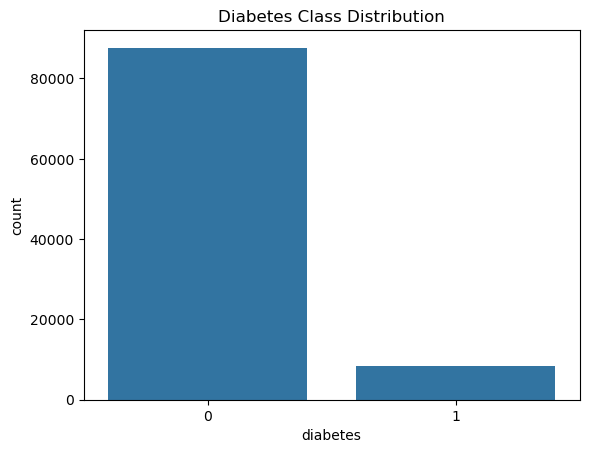

In [11]:
sns.countplot(data=df, x="diabetes")
plt.title("Diabetes Class Distribution")
plt.show()

The target variable is diabetes, where 0 represents non-diabetic patients and 1 represents diabetic patients. Checking the class distribution is important because an imbalanced target variable can affect model performance and metric interpretation.

In [12]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes'],
      dtype='object')

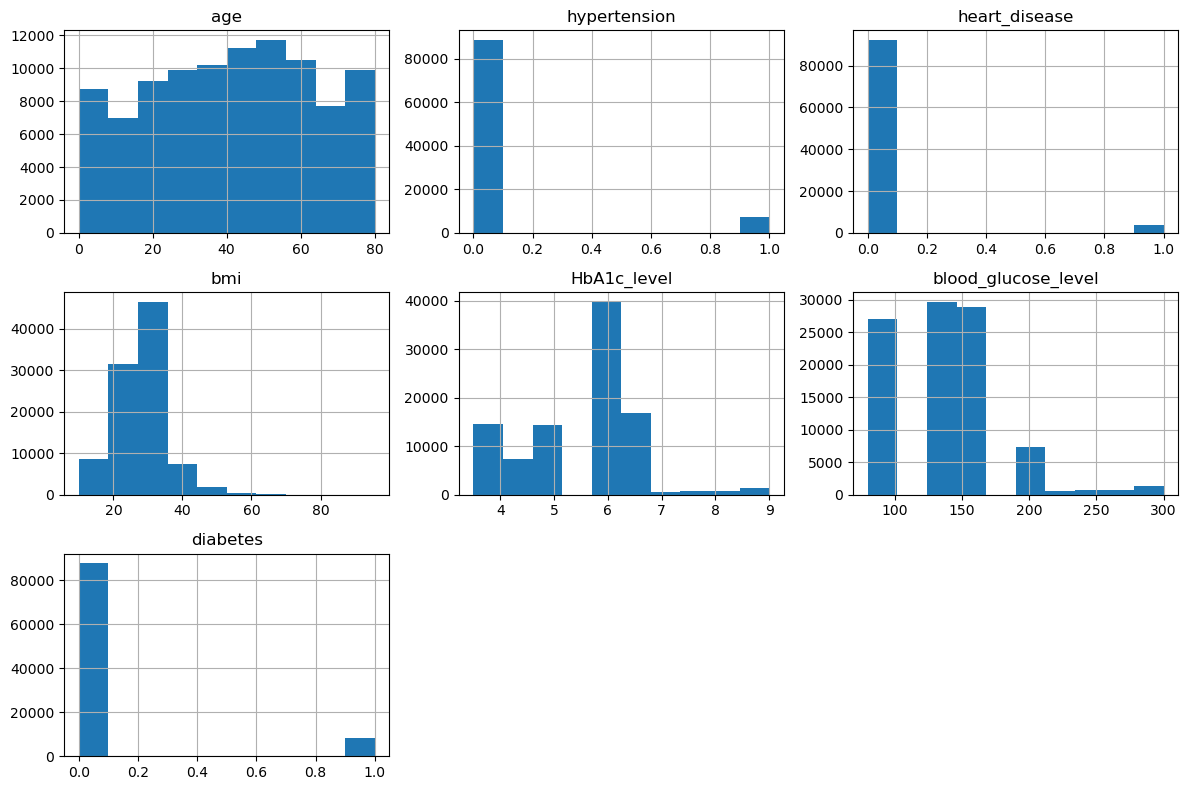

In [13]:
df[numeric_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [14]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols

Index(['gender', 'smoking_history'], dtype='object')

In [15]:
for col in categorical_cols:
    print(df[col].value_counts())
    print()

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64



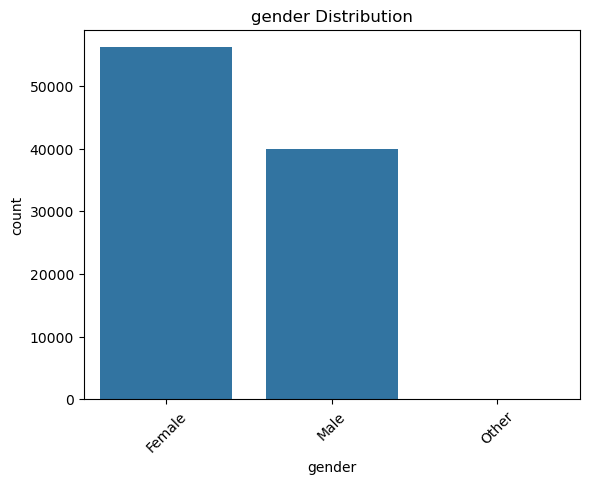

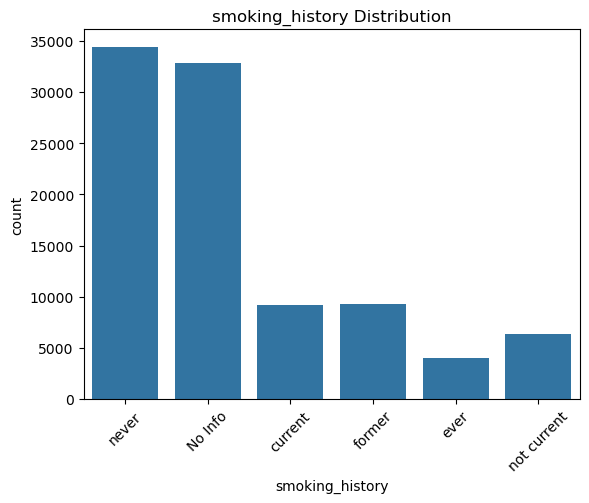

In [16]:
for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

In [17]:
df.groupby("diabetes")[numeric_cols].mean()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
diabetes,,,,,,,
0,39.943229,0.061314,0.030297,26.869003,5.396936,132.818489,0.0
1,60.925961,0.245933,0.149375,31.997755,6.934827,194.026173,1.0


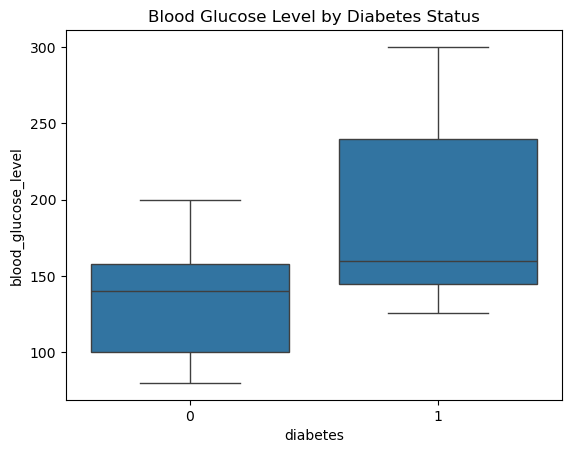

In [18]:
sns.boxplot(data=df, x="diabetes", y="blood_glucose_level")
plt.title("Blood Glucose Level by Diabetes Status")
plt.show()

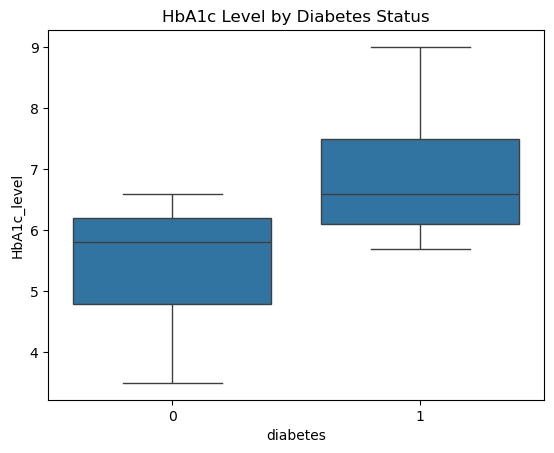

In [19]:
sns.boxplot(data=df, x="diabetes", y="HbA1c_level")
plt.title("HbA1c Level by Diabetes Status")
plt.show()

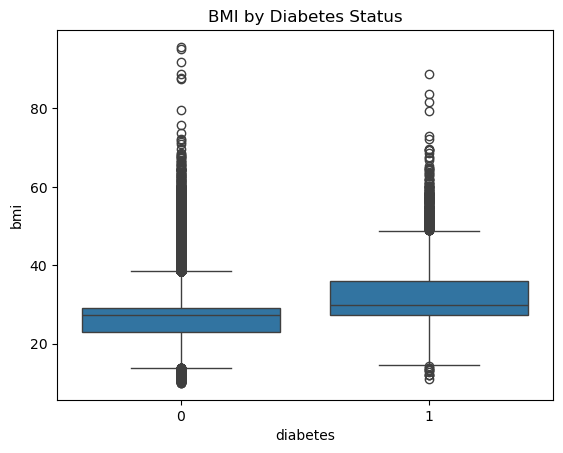

In [20]:
sns.boxplot(data=df, x="diabetes", y="bmi")
plt.title("BMI by Diabetes Status")
plt.show()

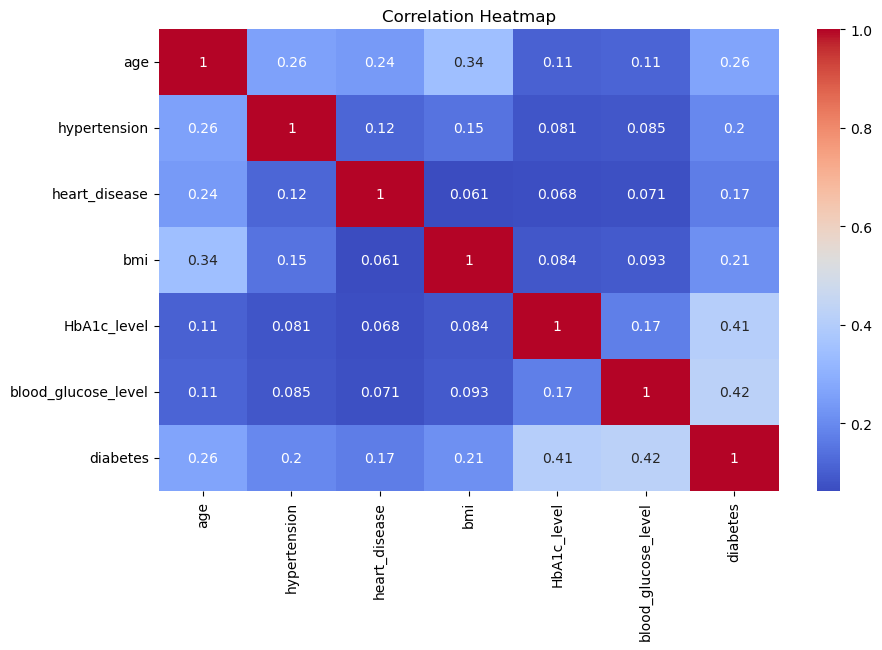

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Key Findings and Next Steps

In this notebook, the diabetes prediction dataset was loaded and examined to understand its general structure. The dataset contains both numerical and categorical features, including demographic information, medical indicators, and the target variable `diabetes`.

The target variable represents whether a patient has diabetes or not. The class distribution was analyzed because imbalanced classes can affect model performance and the interpretation of evaluation metrics.

Initial exploratory data analysis showed that features such as `HbA1c_level`, `blood_glucose_level`, `bmi`, and `age` may be important predictors for diabetes classification. The relationship between numerical features and the target variable was explored using summary statistics and visualizations.

The dataset also contains fully duplicated rows and a very rare category in the `gender` column. These issues were identified in this notebook, but they will be handled in the preprocessing stage.

In the next notebook, the dataset will be cleaned and prepared for machine learning models. This will include removing duplicate rows, handling rare categories, separating features and target variable, applying train-test split, encoding categorical variables, and scaling numerical features.